In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Data
data = pd.read_csv(r"e:\DataSet\study_hours_pass_fail.csv")
data.head()

,study_hours,target
0,3.652032,0
1,7.179229,1
2,3.790951,1
3,5.311606,1
4,1.650429,0


---

### **Code Python**

In [3]:
# Input X
X = data["study_hours"]

# Output y
y = data["target"]

In [ ]:
# Logistic Regression using Gradient Descent
class Logistic_Regression_GD:
    def __init__(self, learning_rate, max_iter):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.w = 0.0
        self.b = 0.0

    def fit(self, feature, target):
        w = self.w
        b = self.b
        n = len(feature)

        for iteration in range (self.max_iter):

            # the sigma symbol part in the formula of partial derivatives for the loss function
            sum_derivative_w = 0.0
            sum_derivative_b = 0.0
            binary_cross_entropy = 0.0

            for i in range (n):
                x_i = feature.iloc[i]                       # x_i value
                z_linear = w * x_i + b                      # linear combination
                probability_i = 1 / (1 + np.exp(-z_linear)) # sigmoid activated to calculate the probability
                y_i = target.iloc[i]                        # class y value

                # Calculating cross entropy
                binary_cross_entropy += -(y_i * np.log(probability_i) + (1 - y_i) * (np.log(1 - probability_i)))

                # Calculating partial derivatives with assigned w and b 
                sum_derivative_w += x_i * (probability_i - y_i)
                sum_derivative_b += probability_i - y_i

            # Final partial derivatives values
            w_gradient = (1 / n) * sum_derivative_w
            b_gradient = (1 / n) * sum_derivative_b

            # Calculating Log Loss
            log_loss = (1 / n) * binary_cross_entropy

            # Algorithm stops iterating when derivatives are close to zero
            if abs(w_gradient) < 1e-4 and abs(b_gradient) < 1e-4:
                break

            # Update parameters (w and b) with GD
            w -= self.learning_rate * w_gradient
            b -= self.learning_rate * b_gradient
    
        # Save results
        self.w = w
        self.b = b

        print(f"The algorithm converged after {iteration+1} iterations")
        print(f"Learning Rate: {self.learning_rate}")
        print(f"Final model's parameters: \nw = {w}\nb = {b}")
        print(f"Log Loss: {log_loss}")

In [5]:
classifier = Logistic_Regression_GD(learning_rate=0.8, max_iter=1700)
classifier.fit(X, y)

The algorithm converged after 1700 iterations
Learning Rate: 0.8
Final model's parameters: 
w = 2.149228171801853
b = -10.103816516167912
Log Loss: 0.22415047227701143


---

> #### **Comparing solutions with sklearn library**

In [6]:
X_sklearn = data[["study_hours"]]
y_sklearn = data["target"]

In [7]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_sklearn, y_sklearn)

print(f"w = {clf.coef_}")
print(f"b = {clf.intercept_}")

w = [[2.14151155]]
b = [-10.07338422]


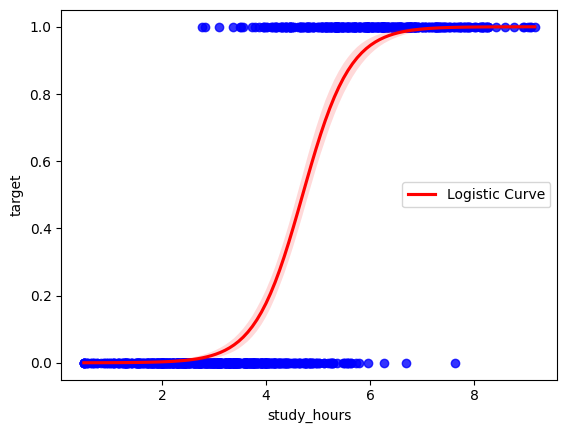

In [8]:
# visualizing the sigmoid/logistic curve
sns.regplot(data=data, x = "study_hours", y = "target", color = 'blue', logistic=True, line_kws={'color':'red', 'label':'Logistic Curve'})
plt.legend()
plt.show()